# Create perturbed $^{235}$U thermal FY files using CEA conservative evaluation

In [1]:
import sandy
import matplotlib.pyplot as plt
from os.path import join, dirname
import pandas as pd
import numpy as np
import random, sys

## Extract FYs and covariance data for U235 thermal fission

If you don't find these files, download them from the [NEA GITLAB repository](https://git.oecd-nea.org/databank/nds/jeff/jeff-lab/fission-yields-u-235-th).

In [2]:
path = join(dirname(sandy.__file__), 'appendix', 'fission_yields')

file_eval = r"mixt_cea-jeff33_u_235_th_eval_c1.stn"
file_cov = r"mixt_cea-jeff33_u_235_th_ind_cov_mat_c1"
tape = sandy.Endf6.from_file(join(path, file_eval))
nfpy = sandy.Fy.from_endf6(tape)

In [3]:
idx = nfpy.data.query(f"E==0.0253 & MT==454").index
ifyth = nfpy.data.loc[idx]

acov = pd.read_csv(join(path, file_cov), sep=r"\s+", header=None)                             # absolute covariance matrix
cov = np.divide(acov.values, ifyth.FY.values.reshape(-1, 1) @ ifyth.FY.values.reshape(1, -1)) # convert to relative terms
cov = sandy.CategoryCov(pd.DataFrame(cov, index=ifyth.ZAP.values, columns=ifyth.ZAP.values))

## Generate perturbation coefficients and write them to file

In [4]:
seed = random.randrange(2**32 - 1)    # create a seed
seed = 1444271359                     # or use always the same
nsmp = 1000                           # sample size
smp = cov.sampling(nsmp, seed=seed)

In [5]:
with pd.ExcelWriter('PERT_92235TH_MF8_MT454.xlsx') as writer:
    pd.DataFrame([[seed]]).to_excel(writer, sheet_name='SEED', columns=None, index=False)
    smp.data.to_excel(writer, sheet_name='IFY_TH')

## Read coefficients from perturbation file and generate random FY ENDF-6 files

Skip the part above if you already have the file of perturbations.

In [6]:
smp = pd.read_excel("PERT_92235TH_MF8_MT454.xlsx", sheet_name="IFY_TH", index_col=0)
smp = sandy.Samples(smp)

In [7]:
idx_ify = nfpy.data.query(f"E==0.0253 & MT==454").index
idx_cfy = nfpy.data.query(f"E==0.0253 & MT==459").index

In [8]:
tape_rdd = sandy.get_endf6_file("jeff_33", "decay", "all")
rdd = sandy.DecayData.from_endf6(tape_rdd)  # this can take a while

In [9]:
smp_min = 0   # write ENDF-6 file only in the sample range [smp_min, smp_max]
smp_max = 99
file_template = "u235_fy_cea_c1_{}.jeff33"
for ismp in range(smp_min, smp_max+1):
    file = file_template.format(ismp)
    f = sandy.Fy(nfpy.data.copy())
    f.data.loc[idx_ify, "DFY"] = f.data.loc[idx_ify, "FY"]            # just for me, i copy the original IFYs where uncertainties should be, so i can compare them to the perturbed ones (anyways I don't use uncertainties)
    f.data.loc[idx_cfy, "DFY"] = f.data.loc[idx_cfy, "FY"]            # same but for CFYs
    f.data.loc[idx_ify, "FY"] *= smp.data[ismp].values                # IMPORTANT, this does not update the CFYs, which in random ENDF-6 file are inconsistent with the perturbed IFYs
    # f = f.apply_qmatrix(922350, 0.0253, rdd, keep_fy_index=True)      # Run this if you want to update the CFYs (slower), or else comment it out
    print(f"writing file '{file}'...")
    f.to_endf6(tape).to_file(file)

writing file 'u235_fy_cea_c1_0.jeff33'...


writing file 'u235_fy_cea_c1_1.jeff33'...


writing file 'u235_fy_cea_c1_2.jeff33'...


writing file 'u235_fy_cea_c1_3.jeff33'...


writing file 'u235_fy_cea_c1_4.jeff33'...


...

writing file 'u235_fy_cea_c1_95.jeff33'...


writing file 'u235_fy_cea_c1_96.jeff33'...


writing file 'u235_fy_cea_c1_97.jeff33'...


writing file 'u235_fy_cea_c1_98.jeff33'...


writing file 'u235_fy_cea_c1_99.jeff33'...


## Compare sample estimates of mass yields with deterministic uncertainty propagation (sandwich formula) 

In [10]:
mfy = {}
for ismp in range(smp_min, smp_max+1):
    mfy[ismp] = sandy.Fy.from_endf6(sandy.Endf6.from_file(f"u235_fy_cea_c1_{ismp}.jeff33")).get_mass_yield(zam=922350, e=0.0253)
mfy = pd.DataFrame(mfy).rename_axis("SMP", axis=1)

S = sandy.Fy(nfpy.data.query("MT==454 and E==0.0253")).get_mass_yield_sensitivity()
C = pd.DataFrame(acov.values, index=ifyth.ZAP.values, columns=ifyth.ZAP.values)
cov_mfy = sandy.CategoryCov(S @ C @ S.T)

mu = nfpy.get_mass_yield(zam=922350, e=0.0253)
sigma = cov_mfy.get_std()

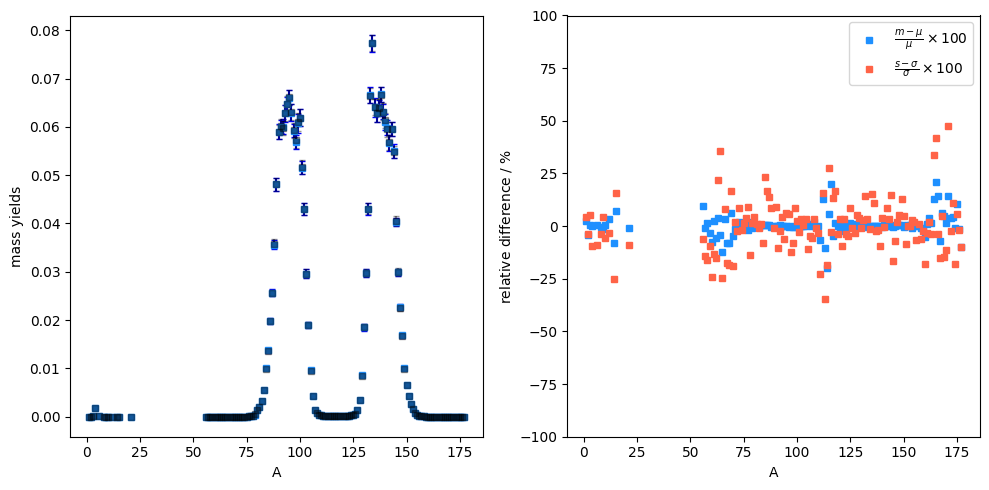

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax = axs[0]
ax.errorbar(x=mfy.index, y=mfy.T.mean(), yerr=mfy.T.std(), marker="s", ms=4, linestyle="none", capsize=2, ecolor="blue", color="dodgerblue", label="sample estimate")
ax.errorbar(x=mu.index, y=mu.values, yerr=sigma.values, marker="s", ms=4, linestyle="none", capsize=2, ecolor="k", color="k", alpha=.4, label="original data")
ax.set(ylabel="mass yields", xlabel="A")

ax = axs[1]
diff_mean = (mfy.T.mean() / mu  - 1) * 100
diff_std = (mfy.T.std() / sigma - 1) * 100
ax.errorbar(x=diff_mean.index, y=diff_mean.values, marker="s", ms=4, linestyle="none", color="dodgerblue", label="$\\frac{m- \\mu}{\\mu} \\times 100$")
ax.errorbar(x=diff_std.index, y=diff_std.values, marker="s", ms=4, linestyle="none", color="tomato", label="$\\frac{s- \\sigma}{\\sigma} \\times 100$")
ax.set(ylim=[-100, 100], ylabel="relative difference / $\\%$", xlabel="A")
ax.legend()
fig.tight_layout()